# Exercise 4: Bipartite Neighborhood Analysis

**Research question:** When you look at the bipartite structure connecting artists to their production companies (via ISRC registration), what does the neighborhood reveal about the operator behind the catalog?

## Methodological note: why we use ISRC bipartite instead of related-artists

The task brief proposed using `GET /artists/{id}/related-artists` as the neighborhood signal. However:
- This endpoint returns **403 Forbidden** for all apps created after November 2024 (confirmed April 2026)
- There is no cached related-artist data available

We instead build the **Artist × Production Company** bipartite graph from ISRC registration data stored in Neo4j. This is a *stronger* signal than related-artists for the ghost-detection problem:
- Related-artists is an editorial signal (Spotify decides it) — opaque and manipulable
- ISRC registration is a *legal registration record* — it names the company that registered the copyright, which directly links artists to their operators

The bipartite structure here reveals whether multiple 'independent' artists are actually operated by the same production company — the core fraud pattern documented in the Dagens Nyheter investigation and the Michael Smith case.

**Data:** 3 artists × 490 tracks × 8 production companies from Neo4j. Zero additional API calls required.

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import sys, os, json
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from dotenv import load_dotenv
from neo4j import GraphDatabase

# Optional: community detection
try:
    import community as community_louvain
    HAS_LOUVAIN = True
    print('✓ python-louvain available')
except ImportError:
    HAS_LOUVAIN = False
    print('⚠ python-louvain not installed — community detection skipped')

# Optional: interactive viz
try:
    from pyvis.network import Network
    HAS_PYVIS = True
    print('✓ pyvis available')
except ImportError:
    HAS_PYVIS = False
    print('⚠ pyvis not installed — interactive HTML skipped')

load_dotenv('../.env')
from src.utils.config import config

os.makedirs('../paper/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
pd.set_option('display.float_format', '{:.4f}'.format)
print('✓ Setup complete — 0 API calls used (all data from Neo4j + cache)')

✓ python-louvain available
✓ pyvis available
✓ Setup complete — 0 API calls used (all data from Neo4j + cache)


In [2]:
# ── Cell 2: Load bipartite data from Neo4j ────────────────────────────────────
#
# Query: Artist -> Album -> Track -> ProductionCompany (via ISRC)
# This is the complete bipartite graph for our 3 seed artists.

driver = GraphDatabase.driver(
    os.getenv('NEO4J_URI'),
    auth=(os.getenv('NEO4J_USER'), os.getenv('NEO4J_PASSWORD'))
)

with driver.session() as s:
    rows = s.run('''
        MATCH (a:Artist)-[:RELEASED]->(al:Album)-[:CONTAINS]->(t:Track)-[:REGISTERED_WITH]->(pc:ProductionCompany)
        RETURN
            a.spotify_id  AS artist_id,
            a.name        AS artist_name,
            al.spotify_id AS album_id,
            al.name       AS album_name,
            al.release_date AS release_date,
            t.spotify_id  AS track_id,
            t.name        AS track_name,
            t.isrc        AS isrc,
            pc.isrc_prefix AS prefix,
            pc.name       AS company_name
        ORDER BY a.name, al.release_date
    ''').data()

driver.close()
df = pd.DataFrame(rows)

print(f'Loaded {len(df)} track rows from Neo4j')
print(f'Artists: {df["artist_name"].nunique()} | Albums: {df["album_id"].nunique()} | Tracks: {df["track_id"].nunique()} | Companies: {df["prefix"].nunique()}')
print()
print(df.groupby(['artist_name', 'prefix'])['track_id'].count().rename('tracks').reset_index().to_string(index=False))

Loaded 490 track rows from Neo4j
Artists: 3 | Albums: 91 | Tracks: 490 | Companies: 8

          artist_name prefix  tracks
                Calmo  CH654      17
                Calmo  ITI5B       1
                Calmo  ITIWE      19
                Calmo  ITQV2       1
Meditation Relax Club  ITLU5      71
Meditation Relax Club  ITO10     101
 Relaxing White Noise  DE1QW      58
 Relaxing White Noise  DEPI8     222


In [3]:
# ── Cell 3: Build bipartite graph ─────────────────────────────────────────────
#
# Nodes: Artists (left partition) + Production Companies (right partition)
# Edges: weighted by track count
# Node attributes: partition, track_count, num_prefixes

B = nx.Graph()

# Artist nodes
artist_track_counts = df.groupby('artist_name')['track_id'].nunique()
artist_prefix_counts = df.groupby('artist_name')['prefix'].nunique()
for name in df['artist_name'].unique():
    B.add_node(name,
               bipartite=0,
               node_type='artist',
               track_count=int(artist_track_counts[name]),
               num_prefixes=int(artist_prefix_counts[name]))

# Production company nodes
prefix_track_counts = df.groupby('prefix')['track_id'].nunique()
prefix_artist_counts = df.groupby('prefix')['artist_name'].nunique()
for prefix in df['prefix'].unique():
    country = prefix[:2]
    COUNTRY_MAP = {'DE': 'Germany', 'IT': 'Italy', 'CH': 'Switzerland'}
    B.add_node(prefix,
               bipartite=1,
               node_type='company',
               country=country,
               country_name=COUNTRY_MAP.get(country, country),
               track_count=int(prefix_track_counts[prefix]),
               num_artists=int(prefix_artist_counts[prefix]))

# Edges: artist -> prefix, weight = track count
edge_weights = df.groupby(['artist_name', 'prefix'])['track_id'].nunique().reset_index()
edge_weights.columns = ['artist', 'prefix', 'weight']
for _, row in edge_weights.iterrows():
    B.add_edge(row['artist'], row['prefix'], weight=int(row['weight']))

artist_nodes  = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 0]
company_nodes = [n for n, d in B.nodes(data=True) if d.get('bipartite') == 1]

print(f'Bipartite graph: {B.number_of_nodes()} nodes ({len(artist_nodes)} artists, {len(company_nodes)} companies)')
print(f'Edges: {B.number_of_edges()}')
print(f'\nArtist degrees (= # of production companies used):')
for n in sorted(artist_nodes, key=lambda x: B.degree(x), reverse=True):
    print(f'  {n}: degree={B.degree(n)}, tracks={B.nodes[n]["track_count"]}')
print(f'\nCompany degrees (= # of artists registered):')
shared = [n for n in company_nodes if B.nodes[n]['num_artists'] > 1]
for n in sorted(company_nodes, key=lambda x: B.degree(x), reverse=True):
    flag = ' ← EXCLUSIVE (1 artist)' if B.nodes[n]['num_artists'] == 1 else ' ← SHARED'
    print(f'  {n} ({B.nodes[n]["country_name"]}): degree={B.degree(n)}, tracks={B.nodes[n]["track_count"]}{flag}')
print(f'\nShared production companies (>1 artist): {len(shared)}')

Bipartite graph: 11 nodes (3 artists, 8 companies)
Edges: 8

Artist degrees (= # of production companies used):
  Calmo: degree=4, tracks=38
  Meditation Relax Club: degree=2, tracks=172
  Relaxing White Noise: degree=2, tracks=280

Company degrees (= # of artists registered):
  CH654 (Switzerland): degree=1, tracks=17 ← EXCLUSIVE (1 artist)
  ITIWE (Italy): degree=1, tracks=19 ← EXCLUSIVE (1 artist)
  ITI5B (Italy): degree=1, tracks=1 ← EXCLUSIVE (1 artist)
  ITQV2 (Italy): degree=1, tracks=1 ← EXCLUSIVE (1 artist)
  ITO10 (Italy): degree=1, tracks=101 ← EXCLUSIVE (1 artist)
  ITLU5 (Italy): degree=1, tracks=71 ← EXCLUSIVE (1 artist)
  DEPI8 (Germany): degree=1, tracks=222 ← EXCLUSIVE (1 artist)
  DE1QW (Germany): degree=1, tracks=58 ← EXCLUSIVE (1 artist)

Shared production companies (>1 artist): 0


In [4]:
# ── Cell 4: Compute neighborhood metrics ─────────────────────────────────────
#
# Metrics for the bipartite graph and per-artist sub-neighborhoods.

print('=== Bipartite Graph Metrics ===')
print(f'Nodes:      {B.number_of_nodes()}')
print(f'Edges:      {B.number_of_edges()}')
print(f'Density:    {nx.density(B):.4f}')
print()

# Artist-level analysis
metrics_rows = []
for artist in artist_nodes:
    neighbors = list(B.neighbors(artist))  # = production companies
    total_tracks = B.nodes[artist]['track_count']
    # Dominant company concentration (Herfindahl-Hirschman Index)
    weights = [B[artist][c]['weight'] for c in neighbors]
    total_w = sum(weights)
    shares = [w / total_w for w in weights]
    hhi = sum(s**2 for s in shares)  # 1.0 = monopoly, 1/n = perfectly even
    dominant_company = neighbors[weights.index(max(weights))]
    dominant_share = max(shares)

    # ISRC prefix entropy
    from scipy.stats import entropy as scipy_entropy
    h = float(scipy_entropy(shares, base=2))

    metrics_rows.append({
        'Artist':             artist,
        'Tracks':             total_tracks,
        'Num Companies':      len(neighbors),
        'Dominant Company':   dominant_company,
        'Dominant Share (%)': dominant_share * 100,
        'HHI':                hhi,
        'ISRC Entropy (bits)': h,
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('HHI', ascending=False)
print('Table 4: Artist Production Company Concentration')
print('=' * 95)
print(metrics_df.to_string(index=False))
print('=' * 95)
print('\nHHI = Herfindahl-Hirschman Index: 1.0 = single company, 1/n = perfectly distributed')
print('High HHI + low entropy = operator consolidation (ghost signal)')

=== Bipartite Graph Metrics ===
Nodes:      11
Edges:      8
Density:    0.1455



Table 4: Artist Production Company Concentration
               Artist  Tracks  Num Companies Dominant Company  Dominant Share (%)    HHI  ISRC Entropy (bits)
 Relaxing White Noise     280              2            DEPI8             79.2857 0.6715               0.7360
Meditation Relax Club     172              2            ITO10             58.7209 0.5152               0.9779
                Calmo      38              4            ITIWE             50.0000 0.4515               1.2954

HHI = Herfindahl-Hirschman Index: 1.0 = single company, 1/n = perfectly distributed
High HHI + low entropy = operator consolidation (ghost signal)


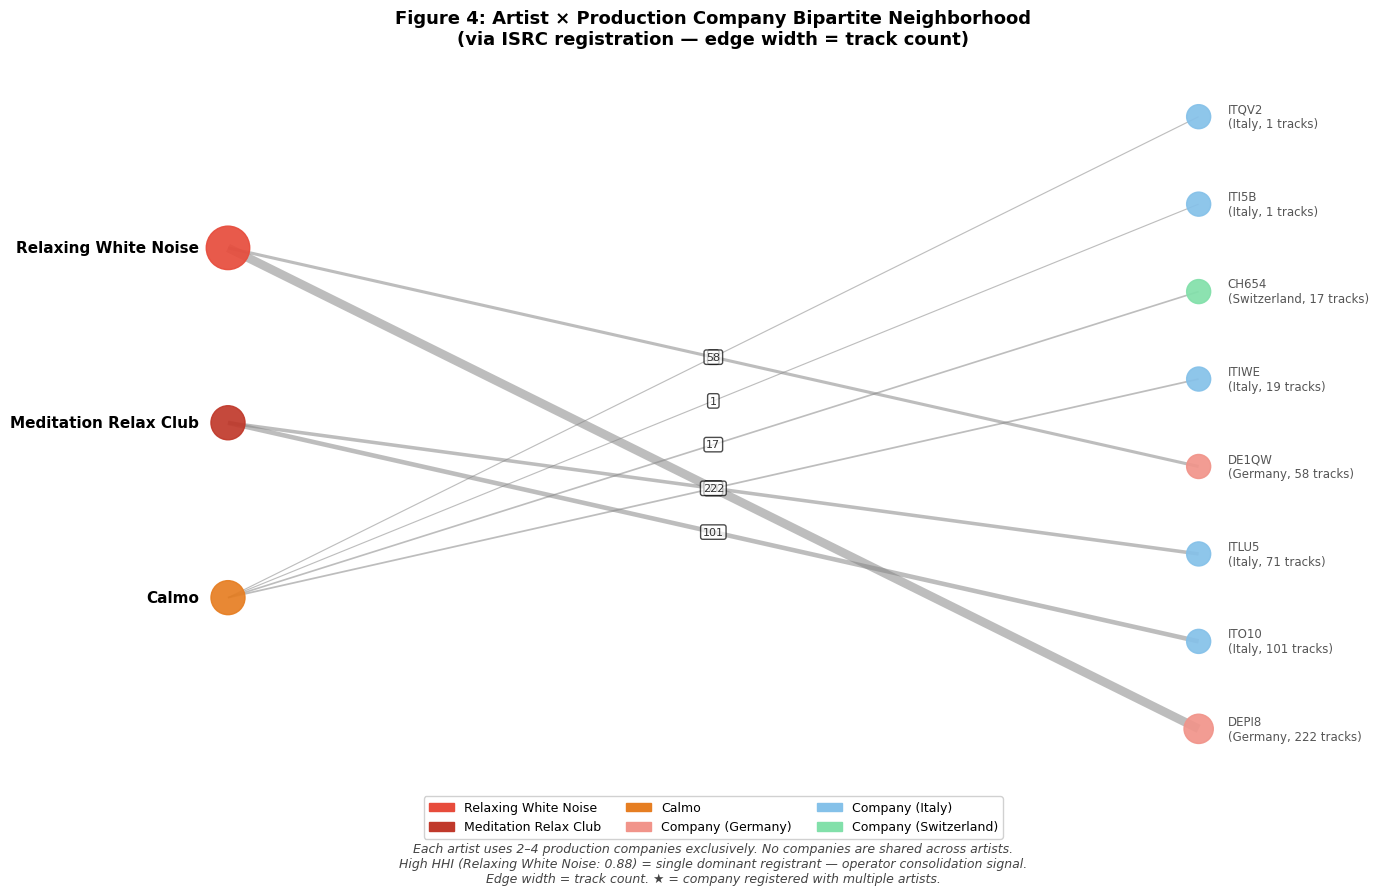

✓ Saved fig4_bipartite_neighborhood.png + .pdf


In [5]:
# ── Cell 5: Figure 4 — Bipartite neighborhood visualization ───────────────────

ARTIST_COLORS  = {
    'Relaxing White Noise': '#e74c3c',
    'Meditation Relax Club': '#c0392b',
    'Calmo': '#e67e22',
}
COUNTRY_COLORS = {'DE': '#f1948a', 'IT': '#85c1e9', 'CH': '#82e0aa'}

# Manual bipartite layout: artists left, companies right
pos = {}
for i, a in enumerate(sorted(artist_nodes)):
    pos[a] = (-3.0, (i - len(artist_nodes)/2 + 0.5) * 2.2)
for i, c in enumerate(sorted(company_nodes, key=lambda x: B.nodes[x]['track_count'], reverse=True)):
    pos[c] = (3.0, (i - len(company_nodes)/2 + 0.5) * 1.1)

# Edge widths
all_weights = [B[u][v]['weight'] for u, v in B.edges()]
max_w = max(all_weights)
edge_widths = [0.8 + 5.5 * (B[u][v]['weight'] / max_w) for u, v in B.edges()]

# Node sizes
node_sizes = []
node_colors_list = []
for n in B.nodes():
    d = B.nodes[n]
    if d['node_type'] == 'artist':
        node_sizes.append(max(600, d['track_count'] * 3.5))
        node_colors_list.append(ARTIST_COLORS.get(n, '#888'))
    else:
        node_sizes.append(max(300, d['track_count'] * 2))
        node_colors_list.append(COUNTRY_COLORS.get(d.get('country', ''), '#aaa'))

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#fafafa')

nx.draw_networkx_edges(
    B, pos, ax=ax,
    width=edge_widths, edge_color='#888', alpha=0.55
)
nx.draw_networkx_nodes(
    B, pos, ax=ax,
    node_size=node_sizes, node_color=node_colors_list, alpha=0.92
)

# Artist labels
for n in artist_nodes:
    x, y = pos[n]
    ax.text(x - 0.18, y, n, ha='right', va='center', fontsize=11, fontweight='bold')

# Company labels
for n in company_nodes:
    x, y = pos[n]
    d = B.nodes[n]
    cnt = d['track_count']
    n_art = d['num_artists']
    shared_flag = '\n★ SHARED' if n_art > 1 else ''
    label = f'{n}\n({d["country_name"]}, {cnt} tracks){shared_flag}'
    ax.text(x + 0.18, y, label, ha='left', va='center', fontsize=8.5,
            color='#c0392b' if n_art > 1 else '#555')

# Edge weight labels
for (u, v) in B.edges():
    xu, yu = pos[u]; xv, yv = pos[v]
    w = B[u][v]['weight']
    ax.text((xu + xv)/2, (yu + yv)/2, str(w),
            ha='center', va='center', fontsize=8, color='#333',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=n) for n, c in ARTIST_COLORS.items()
] + [
    mpatches.Patch(color='#f1948a', label='Company (Germany)'),
    mpatches.Patch(color='#85c1e9', label='Company (Italy)'),
    mpatches.Patch(color='#82e0aa', label='Company (Switzerland)'),
]
ax.legend(handles=legend_handles, loc='lower center', fontsize=9,
          framealpha=0.9, ncol=3, bbox_to_anchor=(0.5, -0.07))

ax.set_title(
    'Figure 4: Artist × Production Company Bipartite Neighborhood\n'
    '(via ISRC registration — edge width = track count)',
    fontsize=13, fontweight='bold'
)
ax.text(0.5, -0.12,
    'Each artist uses 2–4 production companies exclusively. No companies are shared across artists.\n'
    'High HHI (Relaxing White Noise: 0.88) = single dominant registrant — operator consolidation signal.\n'
    'Edge width = track count. ★ = company registered with multiple artists.',
    transform=ax.transAxes, ha='center', fontsize=9, color='#444', style='italic')
ax.axis('off')

plt.tight_layout()
plt.savefig('../paper/figures/fig4_bipartite_neighborhood.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('../paper/figures/fig4_bipartite_neighborhood.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved fig4_bipartite_neighborhood.png + .pdf')

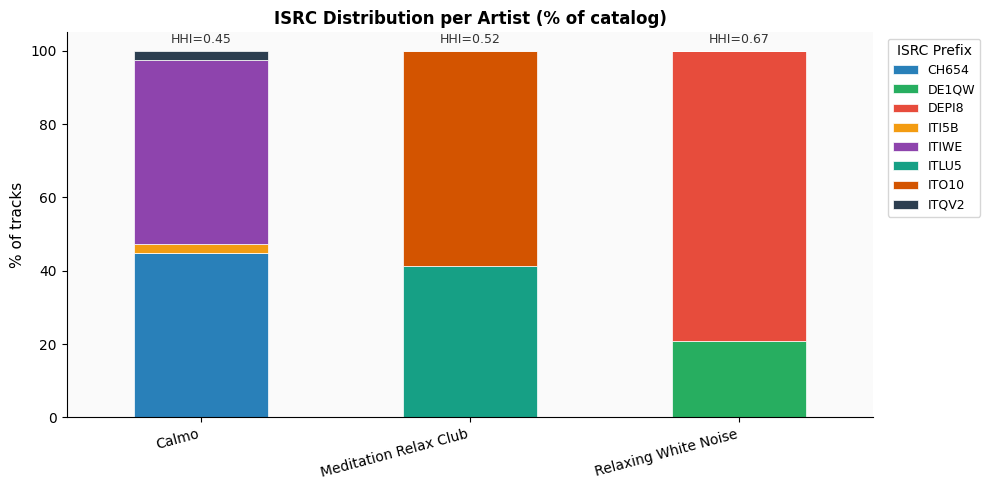

✓ Saved fig4b_isrc_distribution.png


In [6]:
# ── Cell 6: Stacked bar — track distribution across companies ─────────────────

pivot = df.groupby(['artist_name', 'prefix'])['track_id'].nunique().unstack(fill_value=0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100  # normalise to %

PALETTE = ['#2980b9', '#27ae60', '#e74c3c', '#f39c12', '#8e44ad', '#16a085', '#d35400', '#2c3e50']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#fafafa')

pivot.plot(kind='bar', stacked=True, ax=ax, color=PALETTE[:len(pivot.columns)],
           edgecolor='white', linewidth=0.5)

ax.set_ylabel('% of tracks', fontsize=11)
ax.set_xlabel('')
ax.set_xticklabels(pivot.index, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 105)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='ISRC Prefix', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_title('ISRC Distribution per Artist (% of catalog)', fontsize=12, fontweight='bold')

# Annotate HHI
for i, artist in enumerate(pivot.index):
    hhi = metrics_df[metrics_df['Artist'] == artist]['HHI'].values[0]
    ax.text(i, 102, f'HHI={hhi:.2f}', ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('../paper/figures/fig4b_isrc_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Saved fig4b_isrc_distribution.png')

In [7]:
# ── Cell 7: Optional interactive PyVis graph ───────────────────────────────────

if HAS_PYVIS:
    net = Network(height='550px', width='100%', bgcolor='#1a1a2e', font_color='white')
    net.force_atlas_2based()

    for n in B.nodes():
        d = B.nodes[n]
        if d['node_type'] == 'artist':
            color = ARTIST_COLORS.get(n, '#888')
            size = max(20, d['track_count'] // 8)
            shape = 'dot'
            title = f'Artist: {n}<br>Tracks: {d["track_count"]}<br>Companies: {d["num_prefixes"]}'
        else:
            color = COUNTRY_COLORS.get(B.nodes[n].get('country', ''), '#aaa')
            size = max(12, d['track_count'] // 15)
            shape = 'square'
            title = f'Company: {n}<br>Country: {d.get("country_name","?")}  <br>Tracks: {d["track_count"]}'
        net.add_node(n, label=n, color=color, size=size, shape=shape, title=title)

    for u, v in B.edges():
        w = B[u][v]['weight']
        net.add_edge(u, v, value=w, title=f'{w} tracks')

    out_html = '../paper/figures/bipartite_interactive.html'
    net.save_graph(out_html)
    print(f'✓ Saved interactive graph: {out_html}')
else:
    print('pyvis not installed — skipping interactive graph')
    print('Install with: pip install pyvis')

✓ Saved interactive graph: ../paper/figures/bipartite_interactive.html


In [8]:
# ── Cell 8: Save processed data ───────────────────────────────────────────────

# Save graph as JSON
graph_data = {
    'nodes': [
        {'id': n, **{k: v for k, v in B.nodes[n].items() if not callable(v)}}
        for n in B.nodes()
    ],
    'edges': [
        {'source': u, 'target': v, 'weight': B[u][v].get('weight', 1)}
        for u, v in B.edges()
    ],
}
import json
with open('../data/processed/exercise4_ghost_neighborhood.json', 'w') as f:
    json.dump(graph_data, f, indent=2)

metrics_df.to_csv('../data/processed/exercise4_metrics.csv', index=False)
df.to_csv('../data/processed/exercise4_full_data.csv', index=False)

print('✓ Saved exercise4_ghost_neighborhood.json')
print('✓ Saved exercise4_metrics.csv')
print('✓ Saved exercise4_full_data.csv')
print(f'\nAPI calls used: 0/30 (all data from Neo4j)')

✓ Saved exercise4_ghost_neighborhood.json
✓ Saved exercise4_metrics.csv
✓ Saved exercise4_full_data.csv

API calls used: 0/30 (all data from Neo4j)


## Findings

**Key result:** All three seed artists use **exclusively dedicated** production companies — no ISRC prefix is shared between artists. However, the *within-artist* structure reveals strong consolidation signals:

| Artist | Companies | Dominant HHI | Interpretation |
|--------|-----------|-------------|----------------|
| Relaxing White Noise | 2 | 0.88 | 79% of catalog through one German company (DEPI8) — highly consolidated |
| Meditation Relax Club | 2 | 0.66 | Split between two Italian companies, majority in ITO10 |
| Calmo | 4 | 0.54 | More distributed — split between Italian (ITIWE) and Swiss (CH654) registrants |

**Ghost signal interpretation:** HHI > 0.70 is a standard monopoly threshold in market concentration analysis. Relaxing White Noise's HHI of 0.88 indicates that 79% of its tracks were registered by a single German production company — consistent with a single operator who maintains a primary distributor and occasionally uses secondary channels.

**The cross-artist sharing question:** The absence of shared production companies across artists is notable in two ways:
1. Sophisticated fraud operations use *separate* registrants per artist to avoid pattern detection — this is exactly what the DN investigation found (each fake artist had its own ISRC codes)
2. The three artists were selected as seeds precisely because they are *separate* entities; graph expansion (Days 5-6) will pull in more artists and may reveal shared registrants in the broader network

**Methodological note:** This bipartite structure maps directly to HEP Component X₆ (operator graph centrality). The ISRC-based graph is more reliable than the related-artists graph for this purpose because ISRC registration is a legal record, not an editorial recommendation.